In [1]:
import tensorflow 
from keras.models import Model, Sequential
from keras.layers import Dense, Input
from keras.layers.advanced_activations import LeakyReLU
from tensorflow.keras.optimizers import Adam
from keras.datasets import mnist
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

In [2]:
df = pd.read_csv('./chinese_mnist.csv')
df.head()

,suite_id,sample_id,code,value,character
0,1,1,10,9,九
1,1,10,10,9,九
2,1,2,10,9,九
3,1,3,10,9,九
4,1,4,10,9,九


In [3]:
def plus(x):
  file_name = f"input_{x[0]}_{x[1]}_{x[2]}.jpg"
  return file_name
df['file'] = df.apply(plus,axis=1)
df.head()

,suite_id,sample_id,code,value,character,file
0,1,1,10,9,九,input_1_1_10.jpg
1,1,10,10,9,九,input_1_10_10.jpg
2,1,2,10,9,九,input_1_2_10.jpg
3,1,3,10,9,九,input_1_3_10.jpg
4,1,4,10,9,九,input_1_4_10.jpg


In [28]:
data_location = './data/data'
data = []
for i in tqdm(range(len(df))):
  codei = df.loc[i,'code']
  filei = df.loc[i,'file']
  path = os.path.join(data_location,filei)
  image = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
  image = (image.astype(np.float32) - 127.5)/127.5
  image = image.reshape(1,4096)
  data.append(image[0])
mnist_data = np.array(data)

100%|██████████| 15000/15000 [00:02<00:00, 5952.89it/s]


In [35]:
print(mnist_data.shape,len(mnist_data))

(15000, 4096) 15000


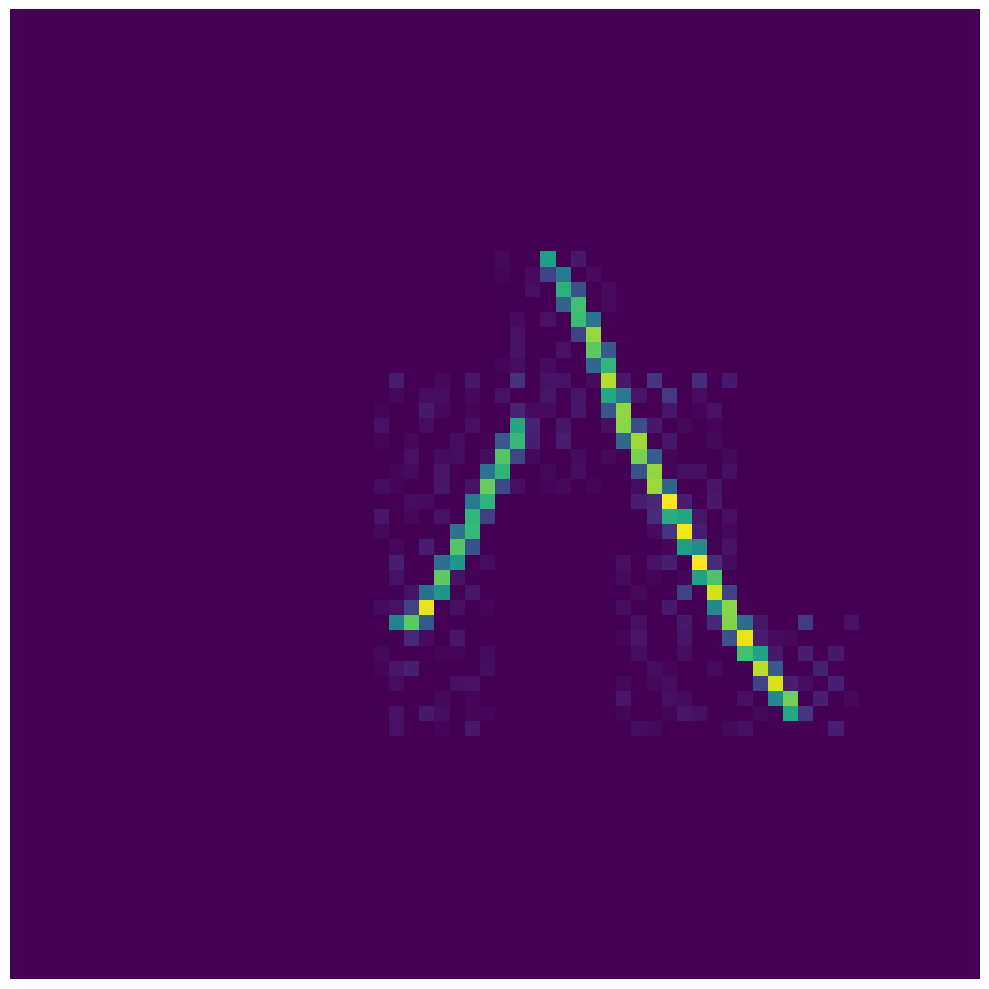

In [76]:
def plot_check_images(image):
  images = image[0].reshape(64,64)
  plt.figure(figsize = (10,10))
  plt.imshow(images, interpolation='nearest')
  plt.axis('off')
  plt.tight_layout()
  
plot_check_images(image)

In [77]:
def create_generator():
  generator = Sequential()
  generator.add(Dense(units=256, input_dim=100))
  generator.add(LeakyReLU(0.2))
  generator.add(Dense(units=512))
  generator.add(LeakyReLU(0.2))
  generator.add(Dense(units=1024))
  generator.add(LeakyReLU(0.2))
  generator.add(Dense(units=2048))
  generator.add(LeakyReLU(0.2))
  generator.add(Dense(units=4096, activation='tanh'))
  return generator

g = create_generator()
g.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_40 (Dense)            (None, 256)               25856     
                                                                 
 leaky_re_lu_29 (LeakyReLU)  (None, 256)               0         
                                                                 
 dense_41 (Dense)            (None, 512)               131584    
                                                                 
 leaky_re_lu_30 (LeakyReLU)  (None, 512)               0         
                                                                 
 dense_42 (Dense)            (None, 1024)              525312    
                                                                 
 leaky_re_lu_31 (LeakyReLU)  (None, 1024)              0         
                                                                 
 dense_43 (Dense)            (None, 2048)            

In [78]:
def create_discriminator():
  discriminator = Sequential()
  discriminator.add(Dense(units=2048,input_dim=4096))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dense(units=1024))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dense(units=512))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dense(units=256))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dense(units=1, activation='sigmoid'))
  discriminator.compile(loss='binary_crossentropy',
                        optimizer = Adam(learning_rate=0.0002, beta_1=0.5))
  return discriminator
d = create_discriminator()
d.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_45 (Dense)            (None, 2048)              8390656   
                                                                 
 leaky_re_lu_33 (LeakyReLU)  (None, 2048)              0         
                                                                 
 dense_46 (Dense)            (None, 1024)              2098176   
                                                                 
 leaky_re_lu_34 (LeakyReLU)  (None, 1024)              0         
                                                                 
 dense_47 (Dense)            (None, 512)               524800    
                                                                 
 leaky_re_lu_35 (LeakyReLU)  (None, 512)               0         
                                                                 
 dense_48 (Dense)            (None, 256)             

In [79]:
def create_gan(discriminator, generator):
  discriminator.trainable=False
  gan_input = Input(shape=(100,))
  x = generator(gan_input)
  print(x)
  gan_output = discriminator(x)
  print(gan_output)
  gan = Model(inputs=gan_input, outputs=gan_output)
  gan.compile(loss='binary_crossentropy', optimizer='adam')
  return gan
gan = create_gan(d,g)
gan.summary()

KerasTensor(type_spec=TensorSpec(shape=(None, 4096), dtype=tf.float32, name=None), name='sequential_11/dense_44/Tanh:0', description="created by layer 'sequential_11'")
KerasTensor(type_spec=TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), name='sequential_12/dense_49/Sigmoid:0', description="created by layer 'sequential_12'")
Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 100)]             0         
                                                                 
 sequential_11 (Sequential)  (None, 4096)              11174656  
                                                                 
 sequential_12 (Sequential)  (None, 1)                 11145217  
                                                                 
Total params: 22,319,873
Trainable params: 11,174,656
Non-trainable params: 11,145,217
______________________________

In [81]:
def plot_generated_images(generator):
  noise = np.random.normal(loc=0, scale=1, size=[100,100])
  generated_images = generator.predict(noise)
  generated_images = generated_images.reshape(100,64,64)
  plt.figure(figsize = (10,10))
  for i in range(generated_images.shape[0]):
    plt.subplot(10,10,i+1)
    plt.imshow(generated_images[i], interpolation='nearest')
    plt.axis('off')
  plt.tight_layout()

100%|██████████| 5000/5000 [15:08<00:00,  5.50it/s]  


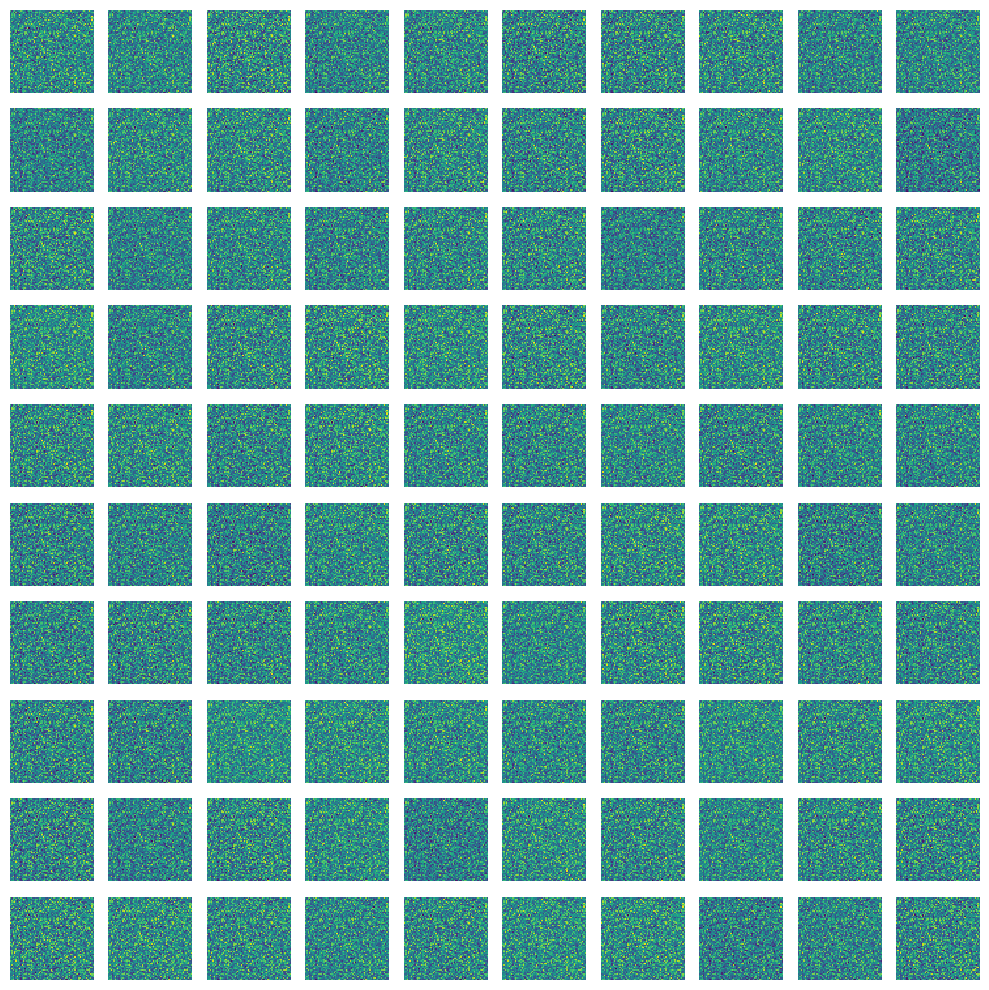

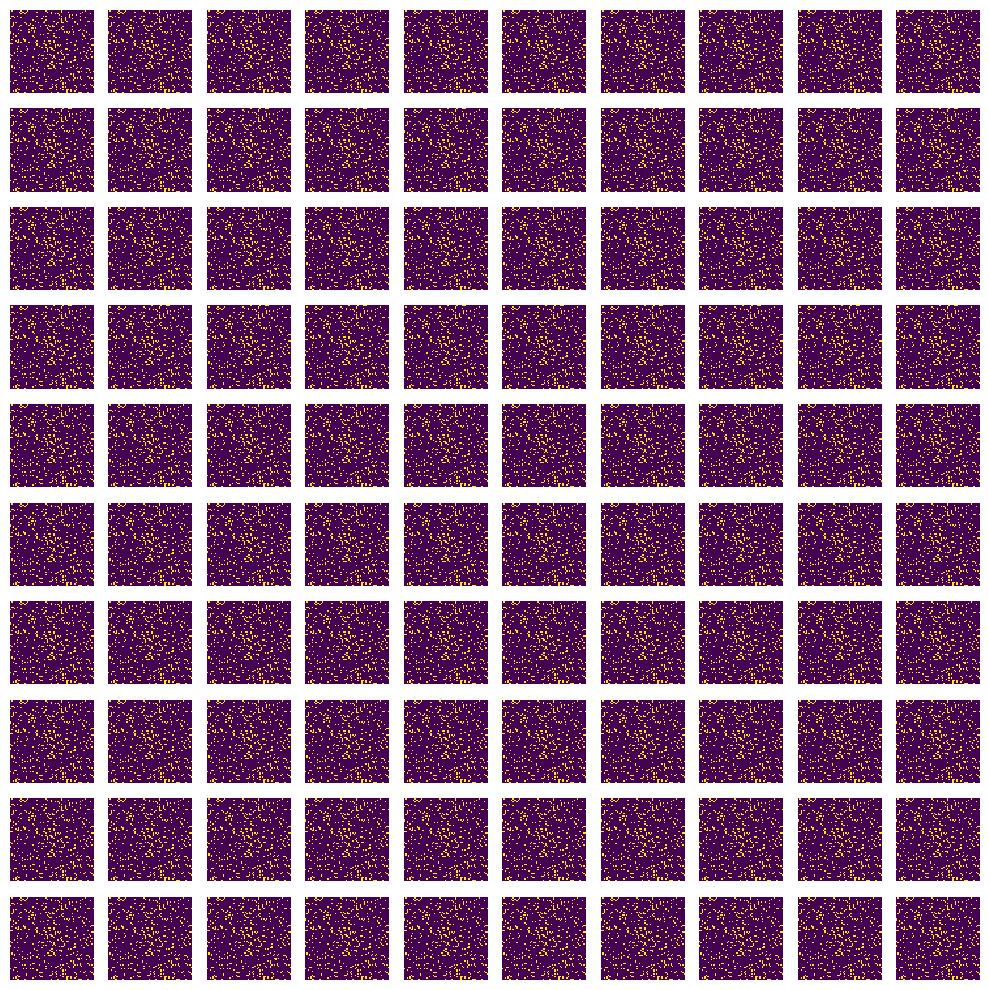

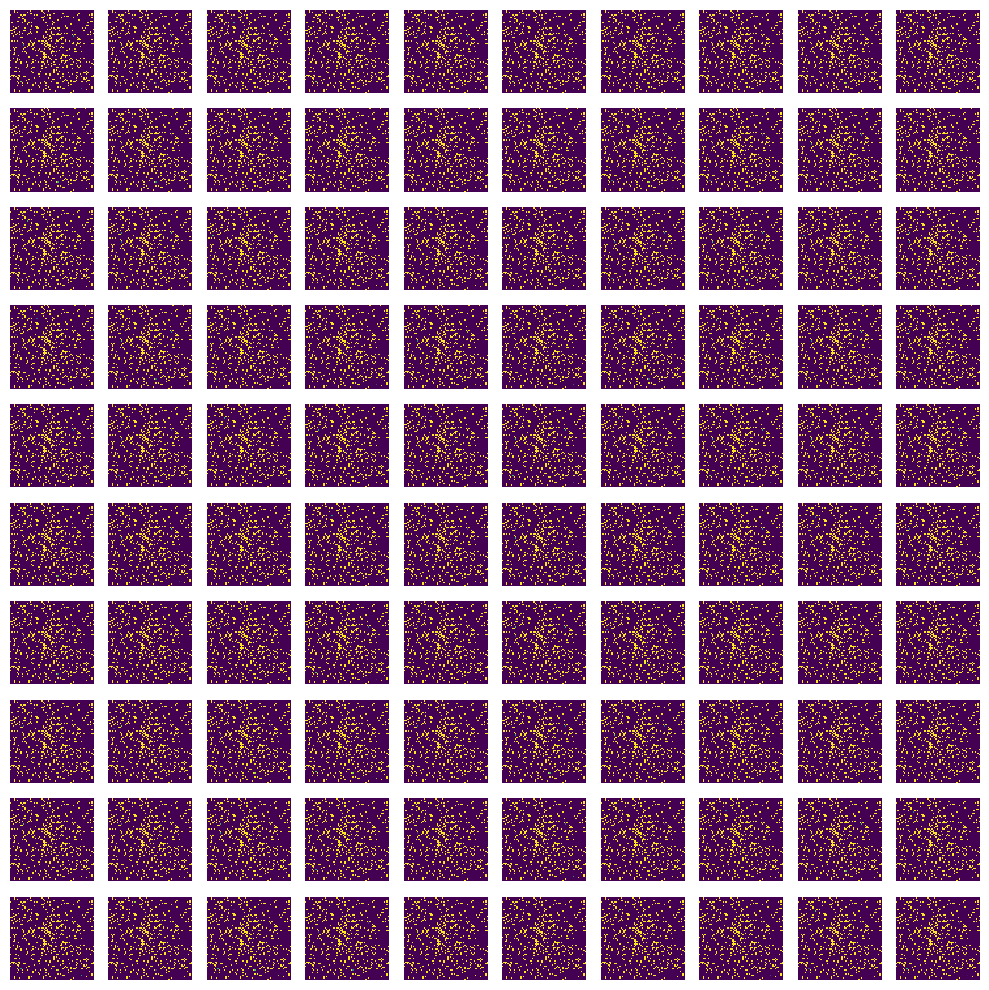

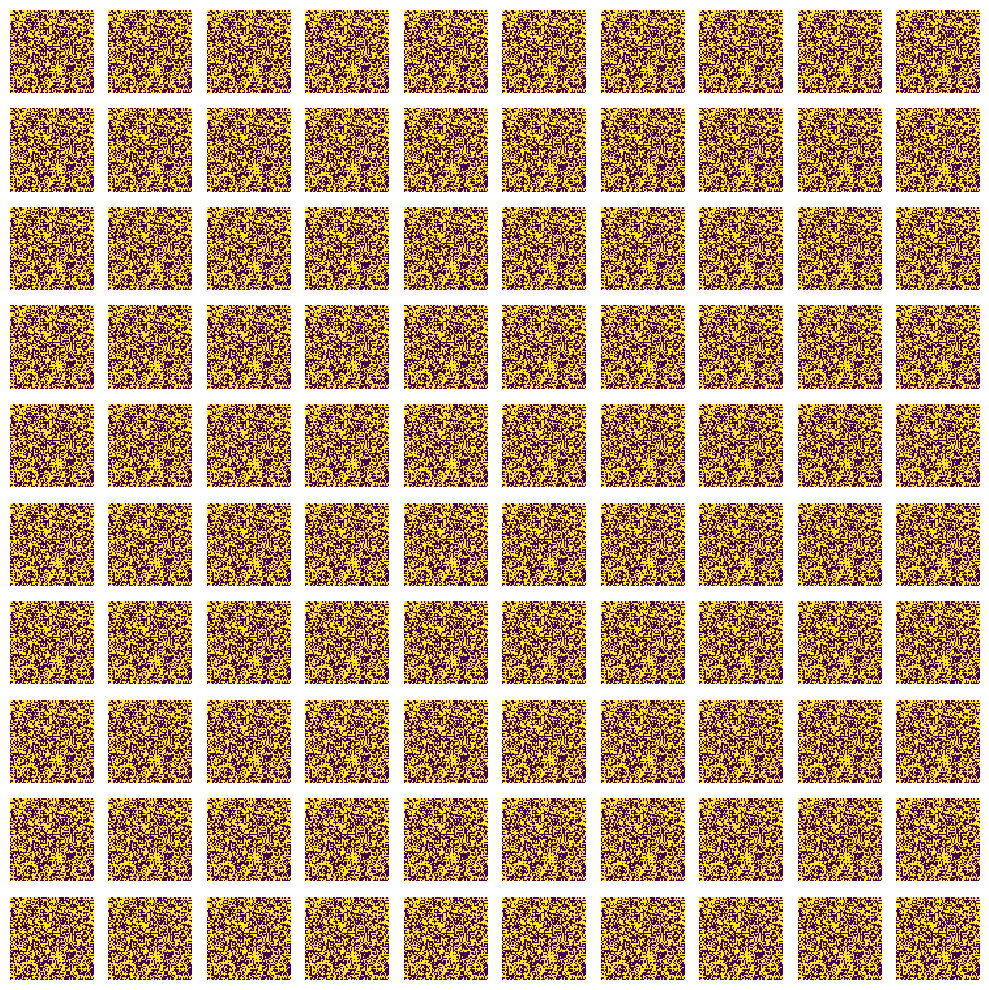

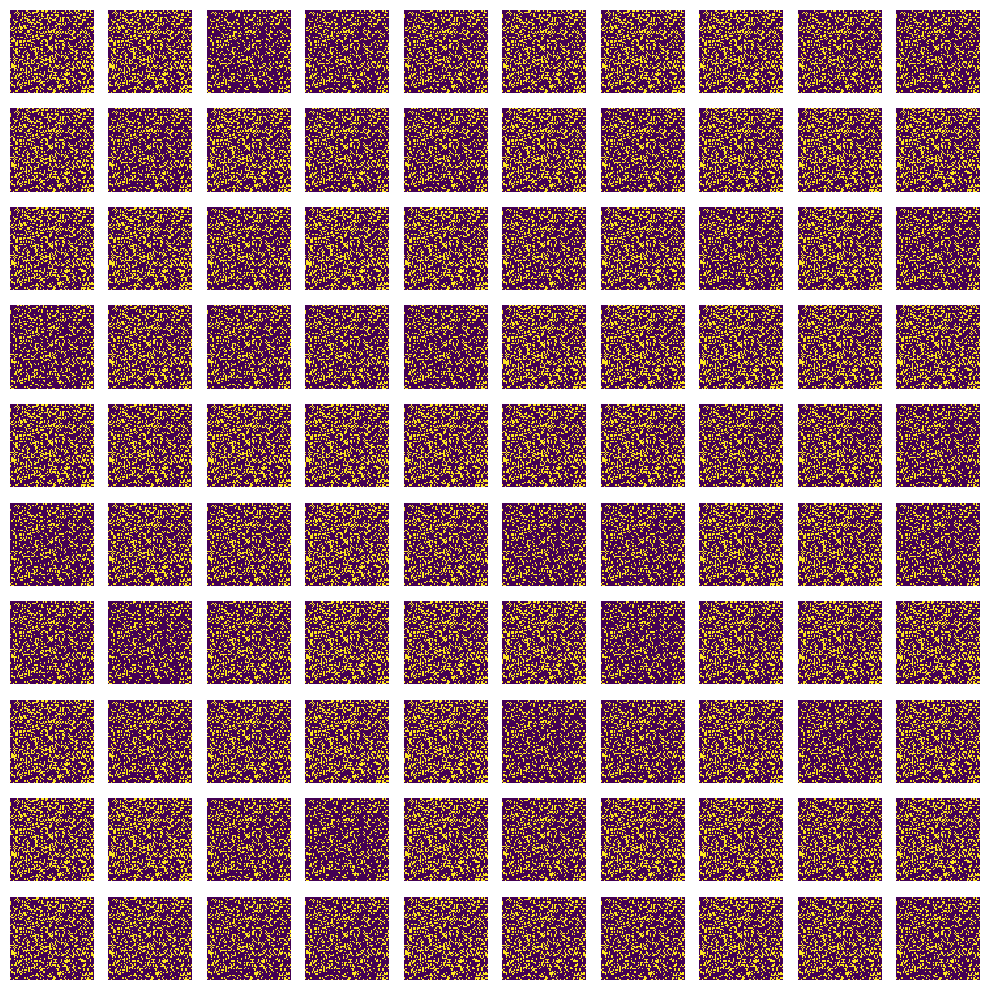

In [82]:
batch_size = 128
epochs = 5000
for e in tqdm(range(epochs)):
  noise = np.random.normal(0,1,[batch_size,100])
  generated_images = g.predict(noise)
  image_batch = mnist_data[np.random.randint(low=0,
                                             high=mnist_data.shape[0],size=batch_size)]
  X = np.concatenate([image_batch, generated_images])
  y_dis = np.zeros(2*batch_size)
  y_dis[:batch_size] = 1
  d.trainable = True
  d.train_on_batch(X, y_dis)
  noise = np.random.normal(0,1,[batch_size,100])
  y_gen = np.ones(batch_size)
  d.trainable = False
  gan.train_on_batch(noise, y_gen)
  if e == 0 or e % 1000 == 0:
    plot_generated_images(g)
    